# Stage 6 – LSTM Form Classifier
## Notebook 2: Model Evaluation

Deep evaluation of the trained BiLSTM on the held-out **test set**.

| Metric | What it tells us |
|--------|------------------|
| Confusion Matrix | Error breakdown per class |
| Precision / Recall / F1 | Class-level performance |
| ROC AUC | Threshold-independent discrimination |
| Confidence histogram | How sure the model is |
| Misclassified rep plots | Visual inspection of hard cases |

In [1]:
# ── 2.0  Imports ──────────────────────────────────────────────────────────────
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score
)

SEED   = 42
DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f'Device: {DEVICE}')

Device: mps


In [2]:
# ── 2.1  Paths ────────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
DS_DIR    = ROOT / 'feature_engineering' / 'data' / 'dataset'
MODEL_DIR = Path('.') / 'models'
CKPT_PATH = MODEL_DIR / 'best_model.pt'
CFG_PATH  = MODEL_DIR / 'model_config.json'

assert CKPT_PATH.exists(), f'Model not found: {CKPT_PATH}'
print('Paths OK')

Paths OK


In [3]:
# ── 2.2  Load dataset & reproduce exact test split ───────────────────────────
X_all = np.load(DS_DIR / 'X.npy').astype(np.float32)
y_all = np.load(DS_DIR / 'y.npy').astype(np.float32)
meta  = pd.read_csv(DS_DIR / 'meta.csv')

# ── reproduce the SAME deterministic split as training notebook ──
idx_all = np.arange(len(X_all))
idx_tv, idx_test = train_test_split(
    idx_all, test_size=0.15, stratify=y_all, random_state=SEED
)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.176,
    stratify=y_all[idx_tv], random_state=SEED
)

X_test  = X_all[idx_test]
y_test  = y_all[idx_test]
meta_test = meta.iloc[idx_test].reset_index(drop=True)

print(f'Total: {len(X_all)}  |  Test: {len(X_test)}')
print(f'Test class balance: correct={int(y_test.sum())}  wrong={int((y_test==0).sum())}')

Total: 157  |  Test: 24
Test class balance: correct=12  wrong=12


In [4]:
# ── 2.3  Rebuild model & load weights ─────────────────────────────────────────
model_cfg = json.loads(CFG_PATH.read_text())

class PushupLSTM(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64,
                 n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = hidden,
            num_layers    = n_layers,
            dropout       = dropout if n_layers > 1 else 0.0,
            batch_first   = True,
            bidirectional = True,
        )
        d = hidden * 2
        self.norm  = nn.LayerNorm(d)
        self.drop1 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(d, 64)
        self.relu  = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        h_cat = self.drop1(self.norm(h_cat))
        return self.fc2(self.drop2(self.relu(self.fc1(h_cat)))).squeeze(1)

model = PushupLSTM(
    n_features = model_cfg['n_features'],
    hidden     = model_cfg['hidden'],
    n_layers   = model_cfg['n_layers'],
    dropout    = model_cfg['dropout'],
).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

THRESHOLD = model_cfg['threshold']
print(f'Loaded best_model.pt  (epoch={ckpt["epoch"]}  val_F1={ckpt["val_f1"]:.4f})')
print(f'Decision threshold: {THRESHOLD}')

Loaded best_model.pt  (epoch=4  val_F1=0.8462)
Decision threshold: 0.5


In [5]:
# ── 2.4  Inference on test set ────────────────────────────────────────────────
Xt = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    logits = model(Xt)
    probs  = torch.sigmoid(logits).cpu().numpy()

y_pred = (probs >= THRESHOLD).astype(int)
y_true = y_test.astype(int)

print('Inference complete.')

Inference complete.


## 2.5  Confusion Matrix

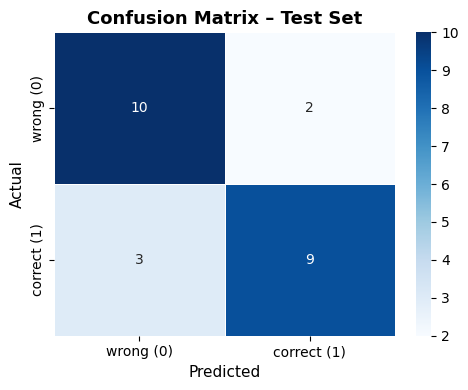

TN=10  FP=2  FN=3  TP=9
Accuracy : 0.792


In [6]:
# ── 2.5  Confusion matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
labels = ['wrong (0)', 'correct (1)']

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual',    fontsize=11)
ax.set_title('Confusion Matrix – Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Accuracy : {(tp+tn)/(tp+tn+fp+fn):.3f}')

## 2.6  Precision · Recall · F1

In [7]:
# ── 2.6  Classification report ────────────────────────────────────────────────
print(classification_report(y_true, y_pred, target_names=['wrong', 'correct']))
print(f'Macro  F1 : {f1_score(y_true, y_pred, average="macro",    zero_division=0):.4f}')
print(f'Weighted F1: {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')

              precision    recall  f1-score   support

       wrong       0.77      0.83      0.80        12
     correct       0.82      0.75      0.78        12

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.79      0.79      0.79        24

Macro  F1 : 0.7913
Weighted F1: 0.7913


## 2.7  ROC Curve & AUC

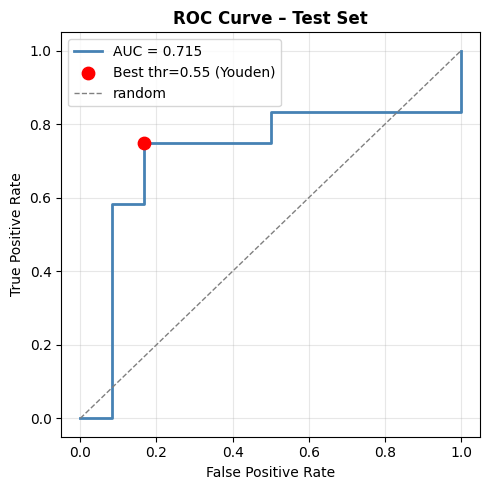

ROC AUC  : 0.7153
Optimal threshold (Youden) : 0.550  (current threshold = 0.5)


In [8]:
# ── 2.7  ROC curve ────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, probs)
auc_score = roc_auc_score(y_true, probs)

# Youden's J: optimal threshold
youden_idx = np.argmax(tpr - fpr)
best_thr   = thresholds[youden_idx]

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_score:.3f}')
ax.scatter(fpr[youden_idx], tpr[youden_idx], s=80, color='red',
           zorder=5, label=f'Best thr={best_thr:.2f} (Youden)')
ax.plot([0,1],[0,1], '--', color='grey', lw=1, label='random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – Test Set', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC AUC  : {auc_score:.4f}')
print(f'Optimal threshold (Youden) : {best_thr:.3f}  '
      f'(current threshold = {THRESHOLD})')

## 2.8  Confidence Histogram

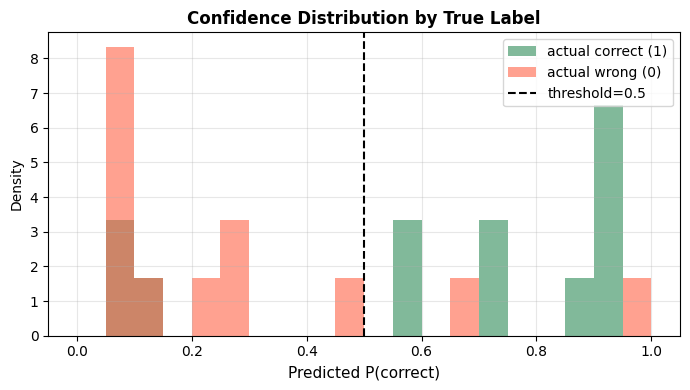

In [9]:
# ── 2.8  Confidence histogram ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 21)

mask_correct = y_true == 1
mask_wrong   = y_true == 0
ax.hist(probs[mask_correct], bins=bins, alpha=0.6, color='seagreen',
        label='actual correct (1)', density=True)
ax.hist(probs[mask_wrong],   bins=bins, alpha=0.6, color='tomato',
        label='actual wrong (0)',   density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5,
           label=f'threshold={THRESHOLD}')

ax.set_xlabel('Predicted P(correct)', fontsize=11)
ax.set_ylabel('Density')
ax.set_title('Confidence Distribution by True Label', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confidence_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.9  Misclassified Rep Visualisation

For each wrong prediction, plot the **mean-elbow-angle trajectory** against a representative correct/wrong baseline.

Misclassified: 5 / 24


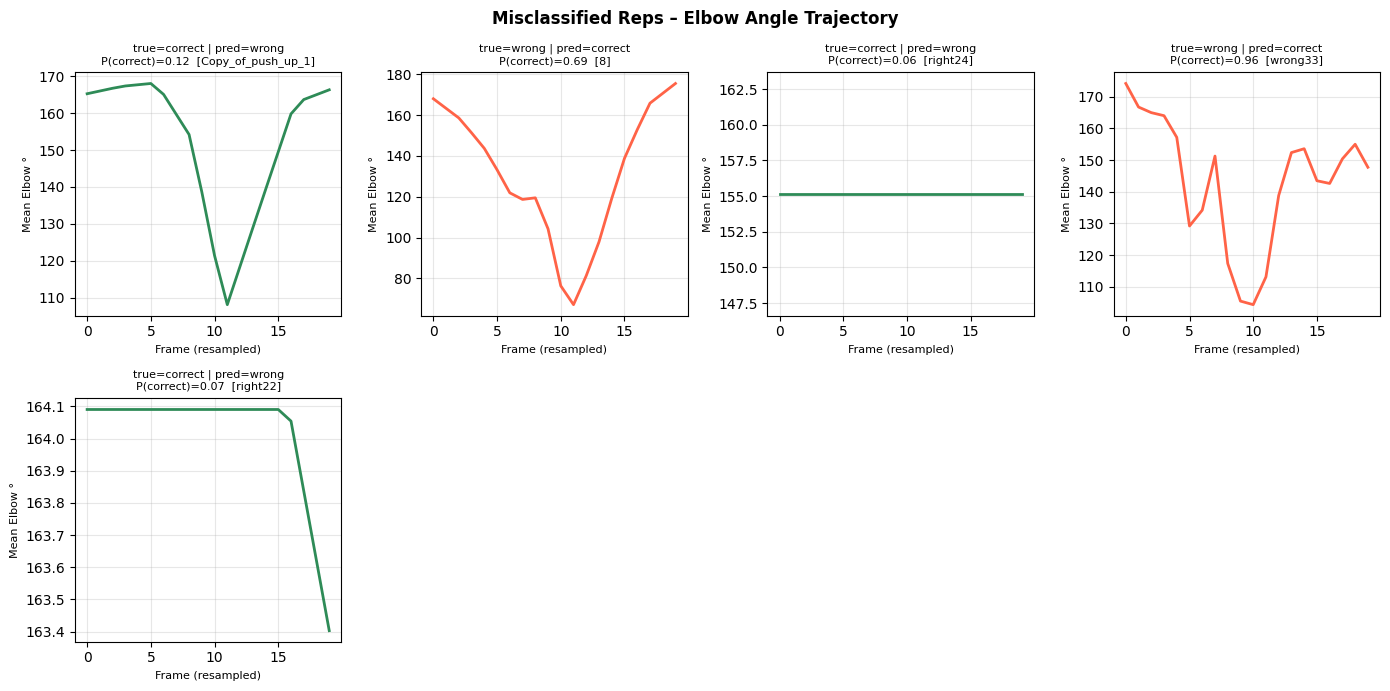

In [10]:
# ── 2.9  Misclassified visualisation ─────────────────────────────────────────
FEATURE_COLS = model_cfg['feature_cols']
FEAT_MEAN    = np.array(model_cfg['feat_mean'], dtype=np.float32)
FEAT_STD     = np.array(model_cfg['feat_std'],  dtype=np.float32)

# Un-normalise for interpretable elbow-angle values
X_test_raw = X_test * FEAT_STD + FEAT_MEAN     # (N_test, T, F)
elbow_idx  = FEATURE_COLS.index('mean_elbow_angle')

# Identify misclassified
wrong_mask  = (y_pred != y_true)
wrong_idxs  = np.where(wrong_mask)[0]

print(f'Misclassified: {wrong_mask.sum()} / {len(y_true)}')

if len(wrong_idxs) == 0:
    print('No misclassifications!')
else:
    n_show = min(len(wrong_idxs), 8)
    ncols  = 4
    nrows  = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows),
                              squeeze=False)
    time_axis = np.arange(X_test.shape[1])

    for plot_i, test_i in enumerate(wrong_idxs[:n_show]):
        ax = axes[plot_i // ncols][plot_i % ncols]
        elbow_traj = X_test_raw[test_i, :, elbow_idx]
        true_lbl   = 'correct' if y_true[test_i] == 1 else 'wrong'
        pred_lbl   = 'correct' if y_pred[test_i] == 1 else 'wrong'
        conf       = probs[test_i]
        row_meta   = meta_test.iloc[test_i]

        color = 'tomato' if true_lbl == 'wrong' else 'seagreen'
        ax.plot(time_axis, elbow_traj, color=color, lw=2)
        ax.set_title(
            f'true={true_lbl} | pred={pred_lbl}\n'
            f'P(correct)={conf:.2f}  [{row_meta.get("video","?")[:25]}]',
            fontsize=8
        )
        ax.set_xlabel('Frame (resampled)', fontsize=8)
        ax.set_ylabel('Mean Elbow °', fontsize=8)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for extra in range(n_show, nrows * ncols):
        axes[extra // ncols][extra % ncols].set_visible(False)

    plt.suptitle('Misclassified Reps – Elbow Angle Trajectory',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'misclassified_reps.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.10  Error Analysis Table

In [11]:
# ── 2.10  Error analysis ──────────────────────────────────────────────────────
df_results = meta_test.copy()
df_results['y_true']     = y_true
df_results['y_pred']     = y_pred
df_results['prob_correct'] = probs.round(3)
df_results['correct']    = (y_pred == y_true)

print('=== Misclassified rows ===')
print(df_results[~df_results['correct']][
    ['video', 'label', 'y_pred', 'prob_correct']
].to_string(index=False))

# Save full results table
df_results.to_csv(MODEL_DIR / 'test_results.csv', index=False)
print(f'\nSaved test_results.csv  ({len(df_results)} rows)')

=== Misclassified rows ===
            video   label  y_pred  prob_correct
Copy_of_push_up_1 correct       0         0.118
                8   wrong       1         0.691
          right24 correct       0         0.065
          wrong33   wrong       1         0.962
          right22 correct       0         0.066

Saved test_results.csv  (24 rows)


## 2.11  Summary

In [12]:
# ── 2.11  Summary ─────────────────────────────────────────────────────────────
acc     = (y_pred == y_true).mean()
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('━'*45)
print('   EVALUATION SUMMARY')
print('━'*45)
print(f'  Test samples  : {len(y_true)}')
print(f'  Accuracy      : {acc:.3f} ({int(acc*len(y_true))}/{len(y_true)})')
print(f'  Macro F1      : {macro_f1:.4f}')
print(f'  ROC AUC       : {auc_score:.4f}')
print(f'  Misclassified : {wrong_mask.sum()}')
print('━'*45)
print(f'  Val F1 (training) : {ckpt["val_f1"]:.4f}')
print(f'  Best epoch        : {ckpt["epoch"]}')
print('━'*45)

# Save summary JSON
summary = {
    'test_accuracy'  : round(float(acc), 4),
    'test_macro_f1'  : round(float(macro_f1), 4),
    'test_roc_auc'   : round(float(auc_score), 4),
    'n_test'         : int(len(y_true)),
    'n_misclassified': int(wrong_mask.sum()),
    'val_f1'         : round(float(ckpt['val_f1']), 4),
    'best_epoch'     : int(ckpt['epoch']),
}
(MODEL_DIR / 'eval_summary.json').write_text(json.dumps(summary, indent=2))
print('Saved eval_summary.json')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   EVALUATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test samples  : 24
  Accuracy      : 0.792 (19/24)
  Macro F1      : 0.7913
  ROC AUC       : 0.7153
  Misclassified : 5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Val F1 (training) : 0.8462
  Best epoch        : 4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Saved eval_summary.json
